In [1]:
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import re
import sys

# Add project root to path for imports
sys.path.insert(0, '/home/michael/code/wandb_dataset')

from base.utils_model import load_model_lite
from analysis.eval import sparse_score

sns.set_style("whitegrid")
sns.set_palette("husl")

In [2]:
def extract_run_info(run_dir):
    """Extract configuration from run directory.
    
    Directory naming convention:
    - Exp (Poisson): exp_{indicator}_t{temp}_{ann|noann}_seed{N}
    - GS (GumbelSoftmax): gs_ub{upperbound}_t{temp}_{ann|noann}_seed{N}
    - GS-adaptive: gs_adaptive_t{temp}_{ann|noann}_seed{N}
    """
    name = run_dir.name
    
    # Determine model type from directory name prefix
    if name.startswith("exp_"):
        # Parse: exp_{indicator}_t{temp}_{ann|noann}_seed{N}
        parts = name.split('_')
        indicator_approx = parts[1]  # sigmoid or cubic
        model_type = f"Exp ({indicator_approx})"
    elif name.startswith("gs_adaptive"):
        # Parse: gs_adaptive_t{temp}_{ann|noann}_seed{N}
        model_type = "GS-adaptive"
        indicator_approx = None
    elif name.startswith("gs_"):
        # Parse: gs_ub{upperbound}_t{temp}_{ann|noann}_seed{N}
        parts = name.split('_')
        upperbound = int(parts[1][2:])  # ubXX -> XX
        model_type = f"GS-{upperbound}"
        indicator_approx = None
    else:
        model_type = "Unknown"
        indicator_approx = None
    
    # Extract temp from directory name (t001, t01, t03)
    temp_map = {"t001": 0.01, "t01": 0.1, "t03": 0.3}
    temp_stop = None
    for temp_str, temp_val in temp_map.items():
        if f"_{temp_str}_" in name:
            temp_stop = temp_val
            break
    
    # Extract anneal from directory name
    temp_anneal = "_ann_" in name and "_noann_" not in name
    
    # Extract seed
    seed_match = re.search(r'seed(\d+)', name)
    seed = int(seed_match.group(1)) if seed_match else None
    
    # Load configs for additional info
    train_config = {}
    model_config = {}
    
    train_cfg_path = run_dir / "ConfigTrainVAE.json"
    if train_cfg_path.exists():
        with open(train_cfg_path) as f:
            train_config = json.load(f)
    
    model_cfg_path = run_dir / "ConfigPoisVAE.json"
    if model_cfg_path.exists():
        with open(model_cfg_path) as f:
            model_config = json.load(f)
    
    # Extract upperbound_param from model config for GS
    upperbound_param = model_config.get('upperbound_param') if name.startswith("gs_") else None
    
    return {
        'model_type': model_type,
        'seed': seed,
        'temp_stop': temp_stop,
        'temp_anneal': temp_anneal,
        'indicator_approx': indicator_approx,
        'upperbound_param': upperbound_param,
        'train_config': train_config,
        'model_config': model_config,
        'path': run_dir
    }

In [3]:
def load_checkpoint_stats(run_dir, eval_temp=0.0, device='cpu'):
    """Load checkpoint and evaluate at specified temperature."""
    import inspect
    from main.config_vae import ConfigPoisVAE, ConfigTrainVAE
    from main.train_vae import TrainerVAE
    from main.vae import PoissonVAE, GumbelSoftmaxPoissonVAE
    
    # Find the highest epoch checkpoint
    checkpoints = list(run_dir.glob("*VAE+TrainerVAE-*.pt"))
    if not checkpoints:
        return None
    
    latest_checkpoint = sorted(checkpoints, key=lambda p: int(p.stem.split('-')[-1].split('_')[0]))[-1]
    
    try:
        # Determine model type from checkpoint filename or directory name
        is_gumbel = 'GumbelSoftmax' in latest_checkpoint.name or run_dir.name.startswith('gs_')
        
        # Load checkpoint
        checkpoint = torch.load(latest_checkpoint, map_location='cpu', weights_only=False)
        
        # Load model config
        model_cfg_path = run_dir / "ConfigPoisVAE.json"
        with open(model_cfg_path, 'r') as f:
            model_cfg = json.load(f)
        
        # Create model based on type
        cfg = ConfigPoisVAE(**model_cfg)
        if is_gumbel:
            model = GumbelSoftmaxPoissonVAE(cfg, verbose=False)
        else:
            model = PoissonVAE(cfg, verbose=False)
        
        # Load model weights
        model.load_state_dict(checkpoint['model'], strict=False)
        
        # Load training config with filtering of unknown keys
        train_cfg_path = run_dir / "ConfigTrainVAE.json"
        with open(train_cfg_path, 'r') as f:
            train_cfg_dict = json.load(f)
        
        # Get valid parameter names for ConfigTrainVAE
        valid_params = set(inspect.signature(ConfigTrainVAE.__init__).parameters.keys()) - {'self'}
        from base.config_base import BaseConfigTrain
        valid_params |= set(inspect.signature(BaseConfigTrain.__init__).parameters.keys()) - {'self'}
        
        # Filter to only valid params
        filtered_cfg = {k: v for k, v in train_cfg_dict.items() if k in valid_params}
        train_cfg = ConfigTrainVAE(**filtered_cfg)
        
        # Create trainer
        trainer = TrainerVAE(model=model, cfg=train_cfg, device=device, verbose=False)
        
        # Evaluate at specified temp
        with torch.inference_mode():
            data, loss, etc = trainer.forward('vld', temp=eval_temp, full_data=True)
        
        # Extract stats
        z = data['z']  # latent representations (numpy array)
        
        stats = {
            'kl': float(loss['kl'].mean()),
            'recon_loss': float(loss['mse'].mean()),
            'neg_elbo': float(loss['kl'].mean() + loss['mse'].mean()),
            'r2': float(loss['r2'].mean()),  # r2 is in the loss dict from forward()
        }
        
        # Compute portion of zeros in representations (handle both numpy and torch)
        if isinstance(z, torch.Tensor):
            stats['portion_zeros'] = float((z == 0).float().mean())
        else:
            # numpy array
            stats['portion_zeros'] = float(np.mean(z == 0))
        
        # Compute overall performance score: sqrt((1-r2)^2 + (1-portion_zeros)^2)
        r2 = stats['r2']
        pz = stats['portion_zeros']
        if not np.isnan(r2):
            stats['overall_performance'] = float(np.sqrt((1 - r2)**2 + (1 - pz)**2))
        else:
            stats['overall_performance'] = np.nan
        
        # Compute sparsity metrics
        lifetime, population, percents = sparse_score(data['z'], cutoff=0.01)
        stats['lifetime_sparsity'] = float(np.nanmean(lifetime))
        
        return stats
        
    except Exception as e:
        print(f"Error loading {run_dir.name}: {e}")
        import traceback
        traceback.print_exc()
        return None

In [4]:
def collect_data(sweep_dir, eval_temp=0.0, device='cpu'):
    """Collect all run data by evaluating models at specified temperature."""
    data = []
    
    run_dirs = [d for d in sweep_dir.iterdir() if d.is_dir()]
    print(f"Found {len(run_dirs)} run directories")
    
    for i, run_dir in enumerate(run_dirs):
        if (i + 1) % 10 == 0:
            print(f"  Processing {i + 1}/{len(run_dirs)}...")
        
        info = extract_run_info(run_dir)
        stats = load_checkpoint_stats(run_dir, eval_temp=eval_temp, device=device)
        
        if stats:
            data.append({**info, **stats})
    
    return data

In [5]:
# Collect data - evaluate all models at temp=0
sweep_dir = Path("checkpoints/sweep")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Evaluating all models at temp=0.0 on {device}...")
data = collect_data(sweep_dir, eval_temp=0.0, device=device)

# No filtering - use all 90 runs
print(f"✓ Loaded {len(data)} runs")

# Summary by model type
from collections import Counter
model_counts = Counter([d['model_type'] for d in data])
print("\nRuns by model type:")
for model, count in sorted(model_counts.items()):
    print(f"  {model}: {count}")

Evaluating all models at temp=0.0 on cuda...
Found 108 run directories


/home/michael/code/wandb_dataset/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/michael/code/wandb_dataset/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happ

  Processing 10/108...
  Processing 20/108...
  Processing 30/108...
  Processing 40/108...
  Processing 50/108...
  Processing 60/108...
  Processing 70/108...
  Processing 80/108...
  Processing 90/108...
  Processing 100/108...
✓ Loaded 106 runs

Runs by model type:
  Exp (cubic): 18
  Exp (sigmoid): 18
  GS-100: 18
  GS-25: 18
  GS-50: 18
  GS-adaptive: 16


In [6]:
# Prepare data for plotting with all 7 metrics
plot_data = []
for d in data:
    plot_data.append({
        'model': d['model_type'],
        'temp': d['temp_stop'],
        'anneal': d['temp_anneal'],
        'seed': d['seed'],
        'elbo': -d['neg_elbo'],
        'lifetime_sparsity': d.get('lifetime_sparsity', np.nan),
        'kl': d.get('kl', np.nan),
        'recon_loss': d.get('recon_loss', np.nan),
        'r2': d.get('r2', np.nan),
        'portion_zeros': d.get('portion_zeros', np.nan),
        'overall_performance': d.get('overall_performance', np.nan),
    })

print(f"Total data points: {len(plot_data)}")

# Count by model type
from collections import Counter
model_counts = Counter([d['model'] for d in plot_data])
print("\nData points by model:")
for model, count in sorted(model_counts.items()):
    print(f"  {model}: {count}")

# Define all 7 metrics
metrics = [
    ('elbo', 'ELBO'),
    ('lifetime_sparsity', 'Lifetime Sparsity'),
    ('kl', 'KL Divergence'),
    ('recon_loss', 'Reconstruction Loss'),
    ('r2', 'R² Score'),
    ('portion_zeros', 'Portion Zeros'),
    ('overall_performance', 'Overall Performance\n(lower is better)'),
]

# Model order for x-axis (including GS-adaptive)
model_order = ['Exp (sigmoid)', 'Exp (cubic)', 'GS-25', 'GS-50', 'GS-100', 'GS-adaptive']

print(f"\n{len(metrics)} metrics to plot")

Total data points: 106

Data points by model:
  Exp (cubic): 18
  Exp (sigmoid): 18
  GS-100: 18
  GS-25: 18
  GS-50: 18
  GS-adaptive: 16

7 metrics to plot


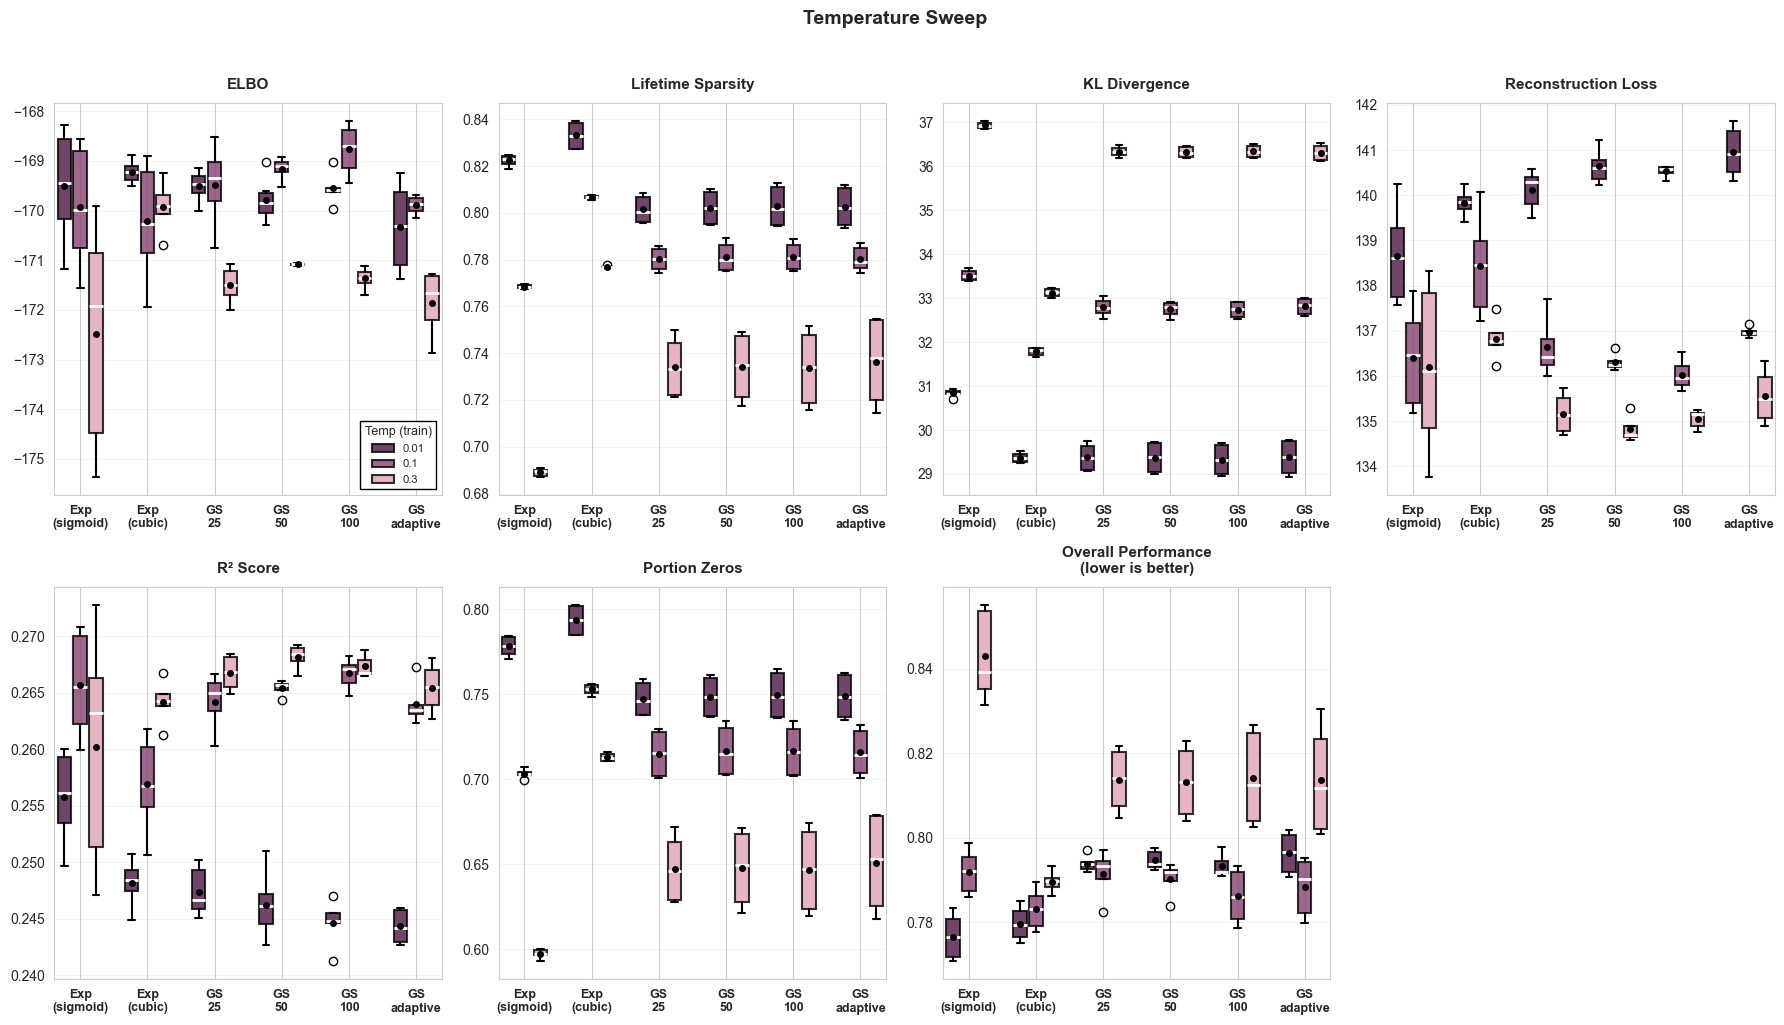

✓ Plot 1: Temperature sweep saved to figures/sweep_temperature.png


In [7]:
# =============================================================================
# PLOT 1: Temperature Sweep
# X-axis: Model types, Colors: Temperature values
# =============================================================================

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

# Define purple gradient colors for temperatures (dark to light)
temp_colors = {
    0.01: "#4A1942",  # dark purple
    0.1: "#834370",   # medium purple  
    0.3: "#DEA3B3",   # light purple
}

temp_order = [0.01, 0.1, 0.3]

# Create legend elements
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=temp_colors[0.01], alpha=0.8, edgecolor='black', linewidth=1.5, label='0.01'),
    Patch(facecolor=temp_colors[0.1], alpha=0.8, edgecolor='black', linewidth=1.5, label='0.1'),
    Patch(facecolor=temp_colors[0.3], alpha=0.8, edgecolor='black', linewidth=1.5, label='0.3'),
]

# Function to remove outliers using robust MAD (Median Absolute Deviation) method
def remove_outliers(values, num_mad=2.5):
    """Remove outliers beyond num_mad MADs from median (robust to extreme outliers)."""
    if len(values) < 2:
        return values
    arr = np.array(values)
    median = np.median(arr)
    mad = np.median(np.abs(arr - median))
    if mad == 0:
        # If MAD is 0, fall back to checking if all values are the same
        return values
    # Modified Z-score using MAD (more robust than standard deviation)
    modified_z_scores = 0.6745 * (arr - median) / mad
    return arr[np.abs(modified_z_scores) <= num_mad].tolist()

# Create each subplot
for idx, (metric_key, metric_title) in enumerate(metrics):
    ax = axes[idx]
    
    # Group by model and temperature for this metric
    from collections import defaultdict
    grouped = defaultdict(list)
    for d in plot_data:
        key = (d['model'], d['temp'])
        value = d[metric_key]
        if value is not None and not np.isnan(value):
            grouped[key].append(value)
    
    # Remove outliers from each group
    for key in grouped.keys():
        grouped[key] = remove_outliers(grouped[key])
    
    # Check if we have any data for this metric
    if not grouped:
        ax.text(0.5, 0.5, f'No data available for {metric_title}', 
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(metric_title, fontsize=12, fontweight='bold', pad=10)
        continue
    
    # Create positions for each model-temp combination
    positions = []
    colors = []
    box_data = []
    
    pos = 0
    box_width = 0.8
    group_spacing = 1.0
    
    for model in model_order:
        for temp in temp_order:
            key = (model, temp)
            if key in grouped and len(grouped[key]) > 0:
                box_data.append(grouped[key])
                positions.append(pos)
                colors.append(temp_colors[temp])
            pos += box_width
        pos += group_spacing
    
    # Calculate center position for each model group
    model_label_positions = []
    model_labels = []
    pos = 0
    for model in model_order:
        num_boxes = len(temp_order)
        center_pos = pos + (num_boxes * box_width) / 2 - box_width / 2
        model_label_positions.append(center_pos)
        model_labels.append(model.replace('Exp ', 'Exp\n').replace('GS-', 'GS\n'))
        pos += num_boxes * box_width + group_spacing
    
    # Create box plot
    if box_data:
        bp = ax.boxplot(box_data, positions=positions, widths=box_width * 0.85, patch_artist=True,
                        showmeans=True,
                        boxprops=dict(linewidth=1.5, edgecolor='black'),
                        medianprops=dict(color='white', linewidth=2),
                        whiskerprops=dict(linewidth=1.5, color='black'),
                        capprops=dict(linewidth=1.5, color='black'),
                        meanprops=dict(marker='o', markerfacecolor='black', markeredgecolor='black', markersize=4))
        
        # Color the boxes by temperature
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.8)
    
    # Set title and labels
    ax.set_title(metric_title, fontsize=11, fontweight='bold', pad=10)
    ax.set_xticks(model_label_positions)
    ax.set_xticklabels(model_labels, fontsize=9, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
    ax.set_axisbelow(True)
    
    # Add legend to first subplot
    if idx == 0:
        ax.legend(handles=legend_elements, title='Temp (train)', 
                  loc='lower right', fontsize=8, title_fontsize=9, framealpha=1.0, 
                  edgecolor='black', fancybox=False, frameon=True, facecolor='white')

# Hide the last subplot (8th) since we only have 7 metrics
axes[7].axis('off')

plt.suptitle('Temperature Sweep', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/sweep_temperature.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Plot 1: Temperature sweep saved to figures/sweep_temperature.png")

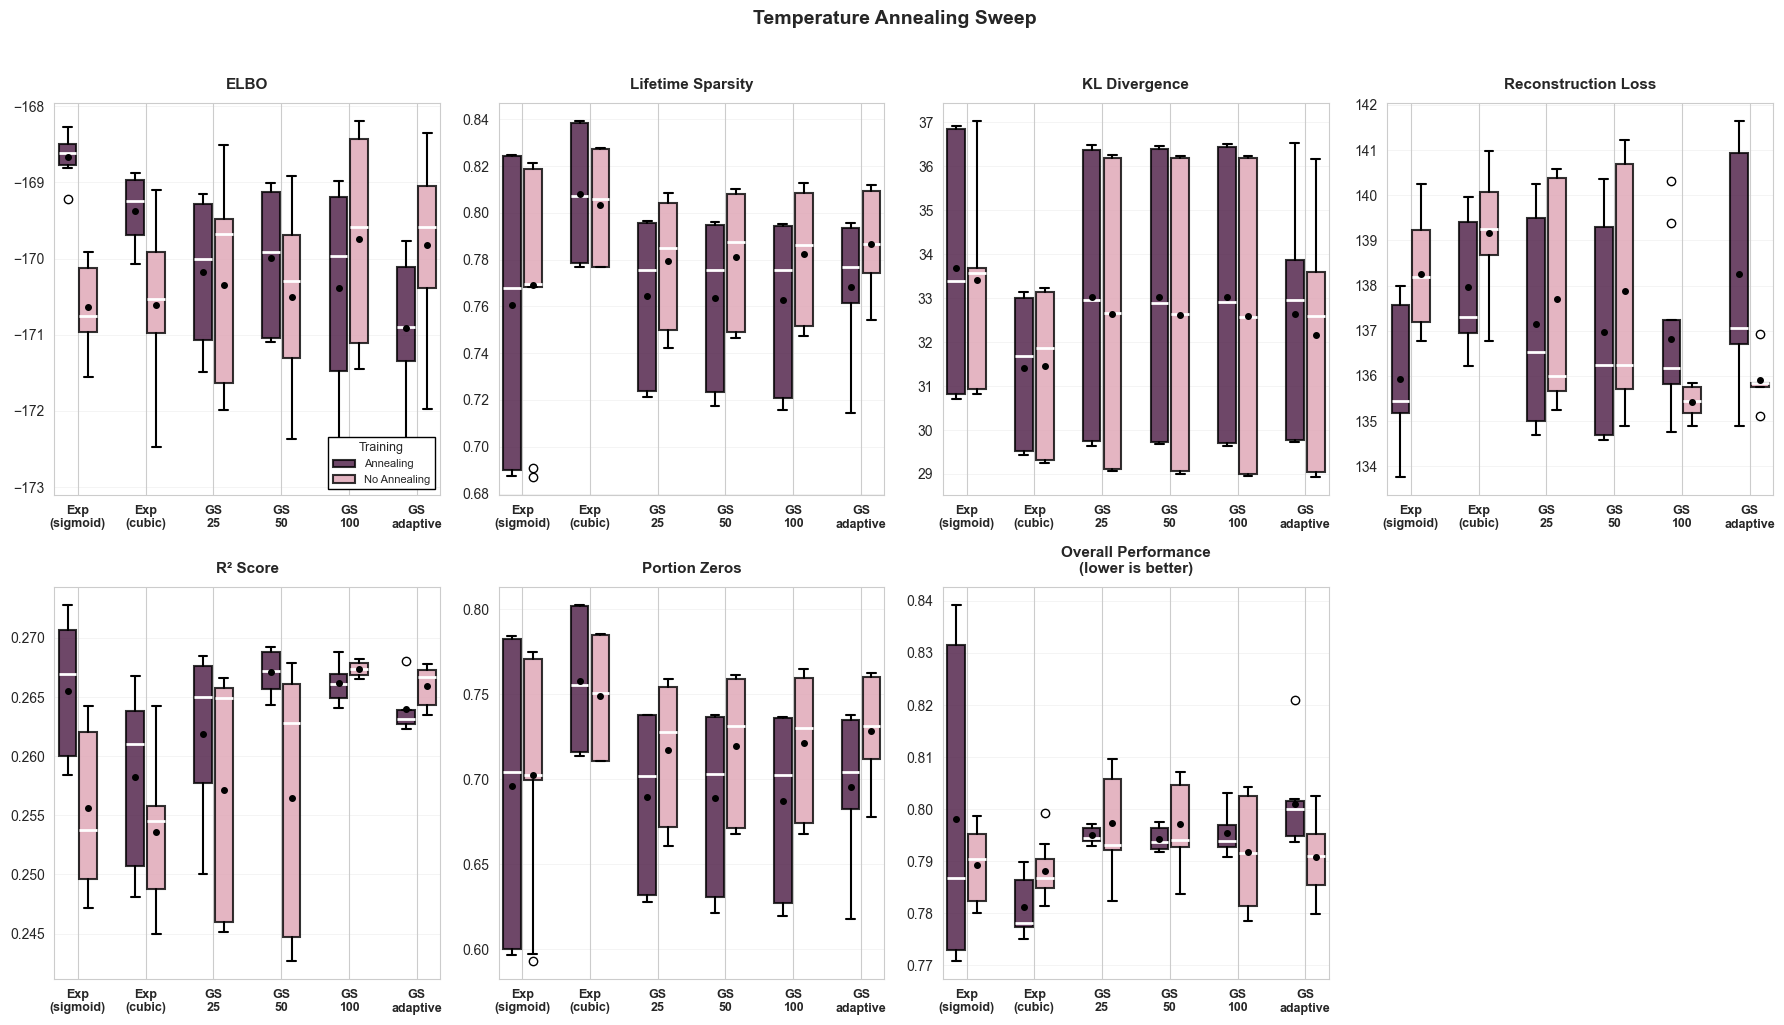

✓ Plot 2: Annealing sweep saved to figures/sweep_annealing.png


In [8]:
# =============================================================================
# PLOT 2: Annealing Sweep
# X-axis: Model types, Colors: Annealing (True/False) with purple gradient
# =============================================================================

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

# Define purple gradient colors for annealing (consistent with temperature plot)
anneal_colors = {
    True: "#4A1942",   # dark purple for annealing
    False: "#DEA3B3",  # light purple for no annealing
}

anneal_order = [True, False]

# Create legend elements
legend_elements = [
    Patch(facecolor=anneal_colors[True], alpha=0.8, edgecolor='black', linewidth=1.5, label='Annealing'),
    Patch(facecolor=anneal_colors[False], alpha=0.8, edgecolor='black', linewidth=1.5, label='No Annealing'),
]

# Function to remove outliers using robust MAD (Median Absolute Deviation) method
def remove_outliers(values, num_mad=2.5):
    """Remove outliers beyond num_mad MADs from median (robust to extreme outliers)."""
    if len(values) < 2:
        return values
    arr = np.array(values)
    median = np.median(arr)
    mad = np.median(np.abs(arr - median))
    if mad == 0:
        # If MAD is 0, fall back to checking if all values are the same
        return values
    # Modified Z-score using MAD (more robust than standard deviation)
    modified_z_scores = 0.6745 * (arr - median) / mad
    return arr[np.abs(modified_z_scores) <= num_mad].tolist()

# Create each subplot
for idx, (metric_key, metric_title) in enumerate(metrics):
    ax = axes[idx]
    
    # Group by model and annealing for this metric
    from collections import defaultdict
    grouped = defaultdict(list)
    for d in plot_data:
        key = (d['model'], d['anneal'])
        value = d[metric_key]
        if value is not None and not np.isnan(value):
            grouped[key].append(value)
    
    # Remove outliers from each group
    for key in grouped.keys():
        grouped[key] = remove_outliers(grouped[key])
    
    # Check if we have any data for this metric
    if not grouped:
        ax.text(0.5, 0.5, f'No data available for {metric_title}', 
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(metric_title, fontsize=12, fontweight='bold', pad=10)
        continue
    
    # Create positions for each model-anneal combination
    positions = []
    colors = []
    box_data = []
    
    pos = 0
    box_width = 0.8
    group_spacing = 1.0
    
    for model in model_order:
        for anneal in anneal_order:
            key = (model, anneal)
            if key in grouped and len(grouped[key]) > 0:
                box_data.append(grouped[key])
                positions.append(pos)
                colors.append(anneal_colors[anneal])
            pos += box_width
        pos += group_spacing
    
    # Calculate center position for each model group
    model_label_positions = []
    model_labels = []
    pos = 0
    for model in model_order:
        num_boxes = len(anneal_order)
        center_pos = pos + (num_boxes * box_width) / 2 - box_width / 2
        model_label_positions.append(center_pos)
        model_labels.append(model.replace('Exp ', 'Exp\n').replace('GS-', 'GS\n'))
        pos += num_boxes * box_width + group_spacing
    
    # Create box plot
    if box_data:
        bp = ax.boxplot(box_data, positions=positions, widths=box_width * 0.85, patch_artist=True,
                        showmeans=True,
                        boxprops=dict(linewidth=1.5, edgecolor='black'),
                        medianprops=dict(color='white', linewidth=2),
                        whiskerprops=dict(linewidth=1.5, color='black'),
                        capprops=dict(linewidth=1.5, color='black'),
                        meanprops=dict(marker='o', markerfacecolor='black', markeredgecolor='black', markersize=4))
        
        # Color the boxes by annealing
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.8)
    
    # Set title and labels
    ax.set_title(metric_title, fontsize=11, fontweight='bold', pad=10)
    ax.set_xticks(model_label_positions)
    ax.set_xticklabels(model_labels, fontsize=9, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
    ax.set_axisbelow(True)
    
    # Add legend to first subplot
    if idx == 0:
        ax.legend(handles=legend_elements, title='Training', 
                  loc='lower right', fontsize=8, title_fontsize=9, framealpha=1.0, 
                  edgecolor='black', fancybox=False, frameon=True, facecolor='white')

# Hide the last subplot (8th) since we only have 7 metrics
axes[7].axis('off')

plt.suptitle('Temperature Annealing Sweep', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/sweep_annealing.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Plot 2: Annealing sweep saved to figures/sweep_annealing.png")